<a href="https://colab.research.google.com/github/NguyenQuan297/CS4410_Assignment_Troy_2026Spring/blob/main/QuanNguyen_CS4410_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading the Data

In [1]:
%matplotlib inline
from sklearn.datasets import load_diabetes

In [3]:
diabetes = load_diabetes()

## Displaying the Dataset's Description

In [7]:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

* Confirm number of **samples/features**, number of **targets**, **feature names**

In [8]:
diabetes.data.shape

(442, 10)

In [9]:
diabetes.target.shape

(442,)

In [10]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

## Exploring the Data with a Pandas

In [11]:
import pandas as pd

In [12]:
pd.set_option('display.precision', 4)

In [13]:
diabetes_df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

In [14]:
diabetes_df['DiseaseProgression'] = pd.Series(diabetes.target)

In [15]:
diabetes_df.head() # peek at first 5 rows

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,DiseaseProgression
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0


In [16]:
diabetes_df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,DiseaseProgression
count,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,4.4200e+02,442.0000
mean,-2.5118e-19,1.2308e-17,-2.2456e-16,-4.7976e-17,-1.3815e-17,3.9184e-17,-5.7772e-18,-9.0425e-18,9.2937e-17,1.1303e-17,152.1335
std,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,4.7619e-02,77.0930
min,-1.0723e-01,-4.4642e-02,-9.0275e-02,-1.1240e-01,-1.2678e-01,-1.1561e-01,-1.0231e-01,-7.6395e-02,-1.2610e-01,-1.3777e-01,25.0000
25%,-3.7299e-02,-4.4642e-02,-3.4229e-02,-3.6656e-02,-3.4248e-02,-3.0358e-02,-3.5117e-02,-3.9493e-02,-3.3246e-02,-3.3179e-02,87.0000
50%,5.3831e-03,-4.4642e-02,-7.2838e-03,-5.6704e-03,-4.3209e-03,-3.8191e-03,-6.5845e-03,-2.5923e-03,-1.9472e-03,-1.0777e-03,140.5000
75%,3.8076e-02,5.0680e-02,3.1248e-02,3.5644e-02,2.8358e-02,2.9844e-02,2.9312e-02,3.4309e-02,3.2432e-02,2.7917e-02,211.5000
max,1.1073e-01,5.0680e-02,1.7056e-01,1.3204e-01,1.5391e-01,1.9879e-01,1.8118e-01,1.8523e-01,1.3360e-01,1.3561e-01,346.0000


## Visualizing the Features

In [22]:
sample_df = diabetes_df.sample(100, random_state=42)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
sns.set_style('whitegrid')

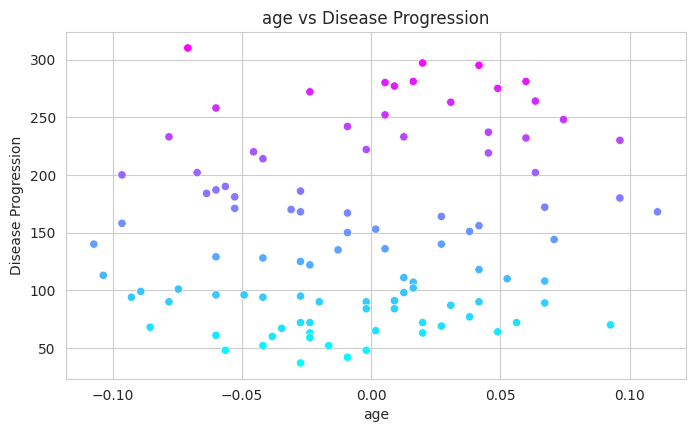

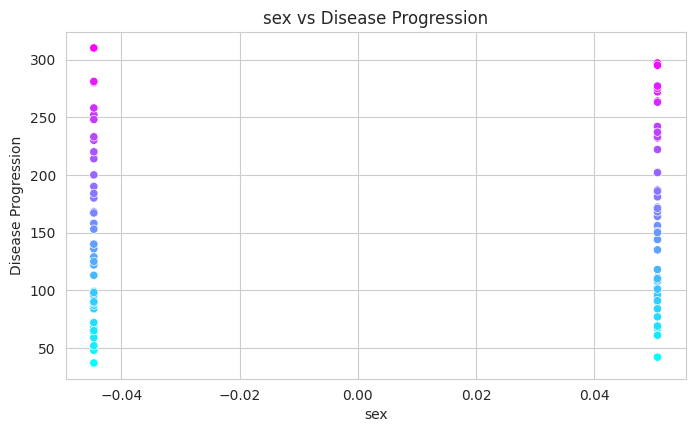

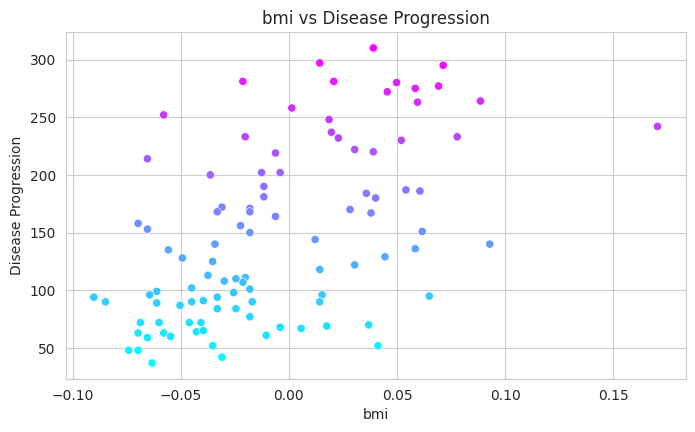

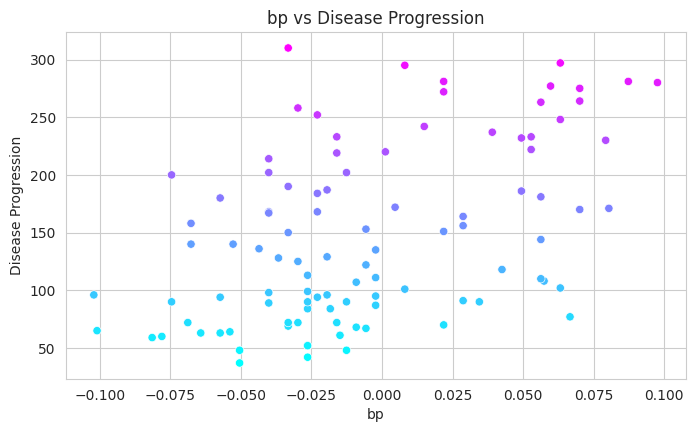

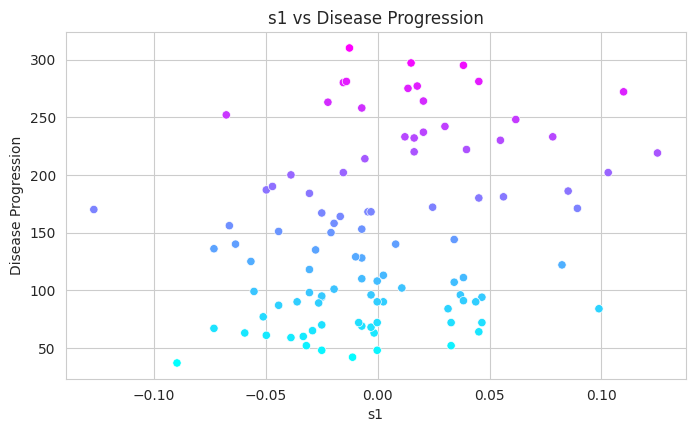

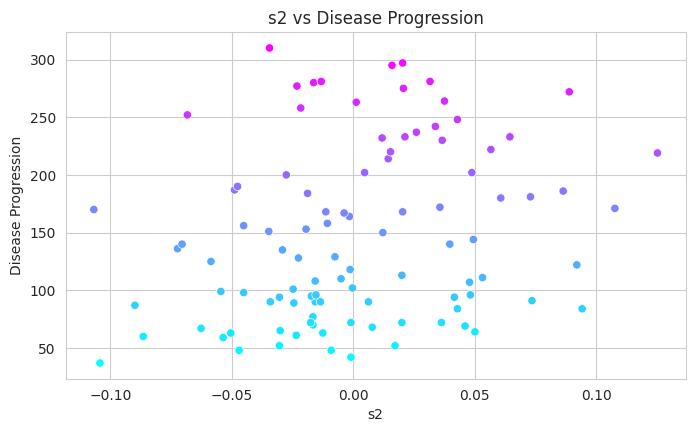

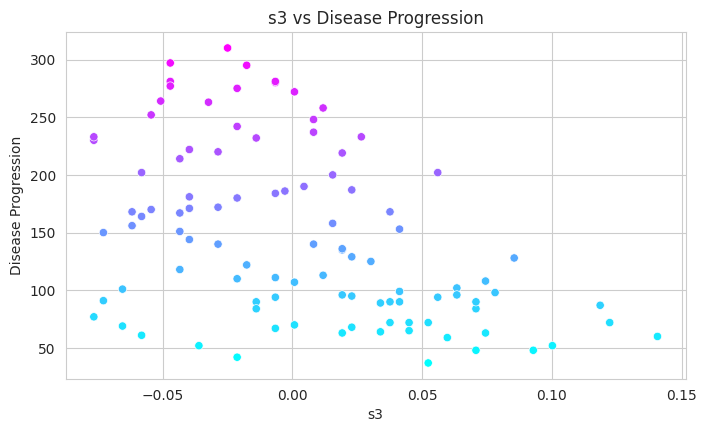

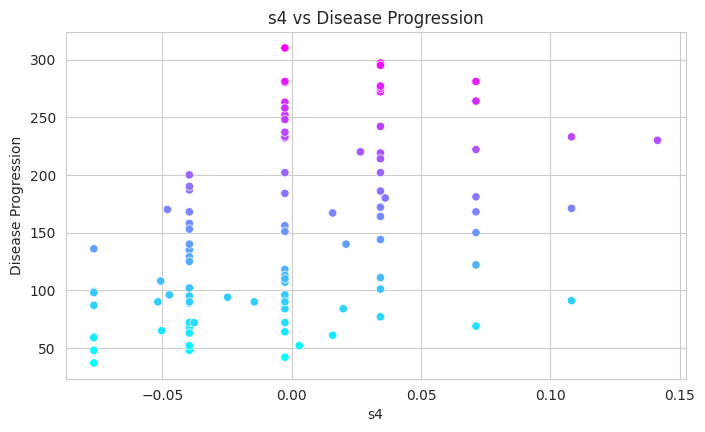

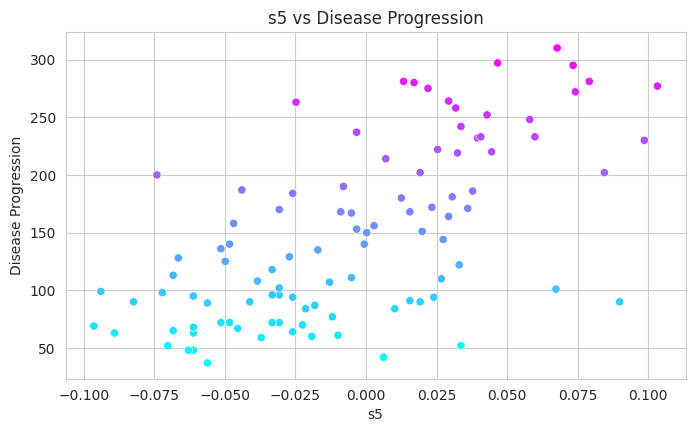

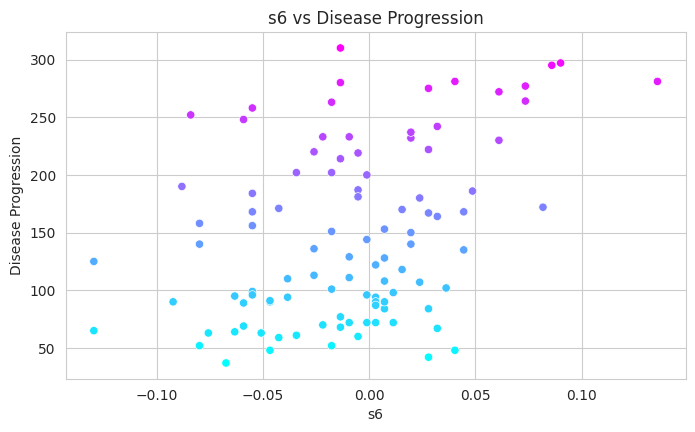

In [28]:
for feature in diabetes.feature_names:
    plt.figure(figsize=(8, 4.5))
    sns.scatterplot(
        data=sample_df,
        x=feature,
        y='DiseaseProgression',
        hue='DiseaseProgression',
        palette='cool',
        legend=False
    )
    plt.title(f'{feature} vs Disease Progression')
    plt.xlabel(feature)
    plt.ylabel('Disease Progression')
    plt.show()

## Splitting the Data for Training and Testing using **train_test_split**

In [29]:
from sklearn.model_selection import train_test_split

In [33]:
X_train, X_test, y_train, y_test = train_test_split(diabetes.data, diabetes.target, random_state=42)

In [34]:
X_train.shape

(331, 10)

In [35]:
X_test.shape

(111, 10)

## Training the Model

In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
linear_regression = LinearRegression()

In [38]:
linear_regression.fit(X=X_train, y=y_train)

LinearRegression()

In [39]:
for i, name in enumerate(diabetes.feature_names):
    print(f'{name:>10}: {linear_regression.coef_[i]}')

       age: 47.74968054051904
       sex: -241.99090727900375
       bmi: 531.9710628796015
        bp: 381.56286182427385
        s1: -918.5029045531496
        s2: 508.2577825194679
        s3: 116.9501644698269
        s4: 269.4923027979242
        s5: 695.8081171154499
        s6: 26.324582028085743


In [40]:
linear_regression.intercept_

np.float64(151.6651755919933)

## Testing the Model

In [41]:
predicted = linear_regression.predict(X_test)

In [42]:
expected = y_test

In [43]:
predicted[:5]

array([137.94908878, 182.533354  , 129.85295373, 292.5630923 ,
       124.86788221])

In [44]:
expected[:5]

array([219.,  70., 202., 230., 111.])

## Visualizing the Expected vs Predicted Prices

In [45]:
df = pd.DataFrame()

In [46]:
df['Expected'] = pd.Series(expected)

In [47]:
df['Predicted'] = pd.Series(predicted)

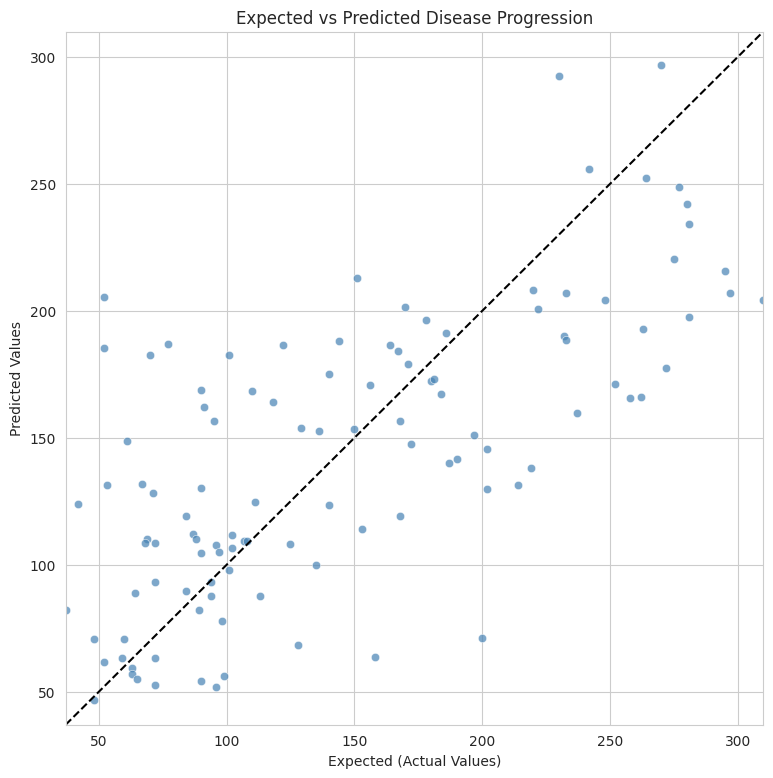

In [49]:
plt.figure(figsize=(9, 9))

sns.scatterplot(
    x=expected,
    y=predicted,
    color='steelblue',
    alpha=0.7
)

start = min(expected.min(), predicted.min())
end = max(expected.max(), predicted.max())

plt.plot([start, end], [start, end], 'k--')

plt.xlabel('Expected (Actual Values)')
plt.ylabel('Predicted Values')
plt.title('Expected vs Predicted Disease Progression')

plt.xlim(start, end)
plt.ylim(start, end)

plt.show()

## Regression Model Metrics

In [50]:
from sklearn import metrics

In [51]:
metrics.r2_score(expected, predicted)

0.4849058889476756

## Choosing the Best Model

In [52]:
from sklearn.linear_model import ElasticNet, Lasso, Ridge

In [53]:
estimators = {
    'LinearRegression': linear_regression,
    'ElasticNet': ElasticNet(),
    'Lasso': Lasso(),
    'Ridge': Ridge()
}

In [54]:
from sklearn.model_selection import KFold, cross_val_score

In [55]:
for estimator_name, estimator_object in estimators.items():
    kfold = KFold(n_splits=10, random_state=42, shuffle=True)
    scores = cross_val_score(estimator=estimator_object,
        X=diabetes.data, y=diabetes.target, cv=kfold,
        scoring='r2')
    print(f'{estimator_name:>16}: ' +
          f'mean of r2 scores={scores.mean():.3f}')

LinearRegression: mean of r2 scores=0.465
      ElasticNet: mean of r2 scores=-0.021
           Lasso: mean of r2 scores=0.325
           Ridge: mean of r2 scores=0.409
